=== Constant Downside-Vol Targeting Backtest ===
Source: Yahoo via vectorbt | Symbol: TLT
Requested analysis window: 2000-01-01 -> 2026-03-23
Warmup start used: 1998-12-31 | Warmup bars target: 262
Rows used for full calc: 5949 | Rows used for final analysis: 5927
First valid input date: 2002-08-29
First actual exposure date: 2002-08-29
Final analysis window: 2002-08-29 -> 2026-03-20
Constant target negative vol: 0.1
Final target vol floor/cap: 0.0 -> 0.2
VolWindows: [21] | Aggregation: MAX | MAR(signal): 0.0
Realized vol floor: 0.01
Max leverage cap: 3.0
Rolling alpha/beta window: 252 days
PointValue: 50.0 | MinLot=1.0, Step=1.0, MaxLot=1e+20
Commission: $4.0/lot/side | Spread: 0.0 pts | Slippage: 0.0 pts
Total costs deducted (analysis window): 560788.00

Strategy stats (rebased to init_cash at first exposure date):
{'total_return': 1.0049900335810316, 'cagr': 0.03002356696638042, 'ann_vol': 0.1694274536611161, 'neg_ann_vol': 0.11945057733727069, 'sharpe': 0.25937118574998635, 'max_dd

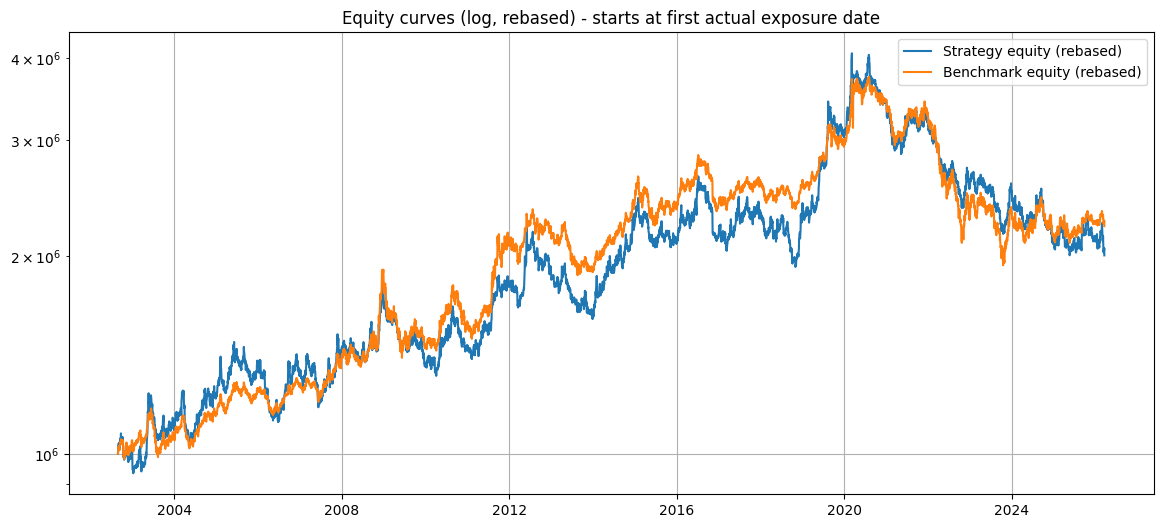

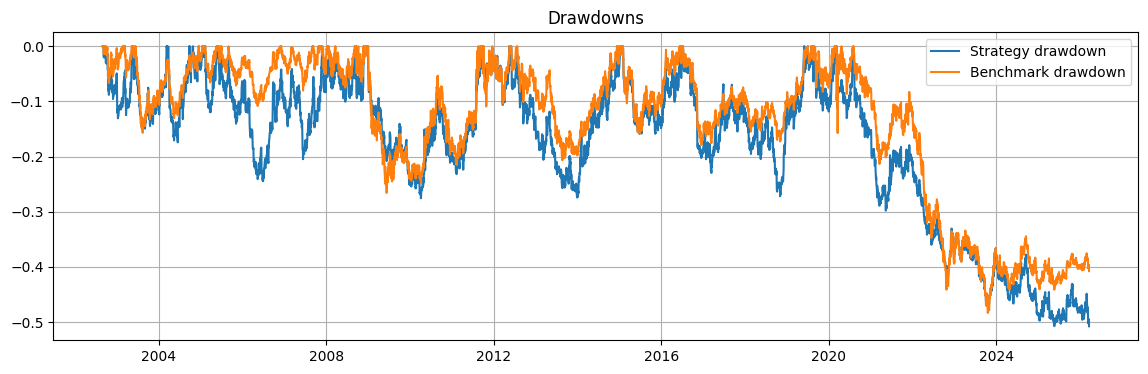

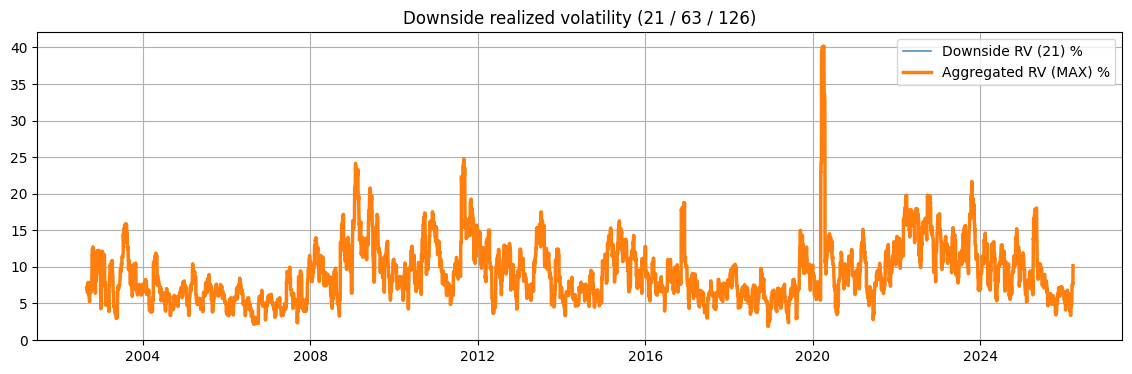

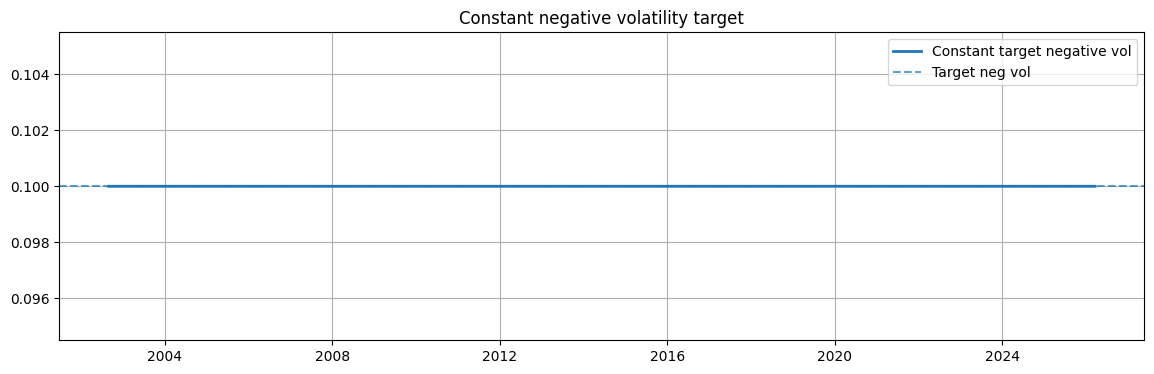

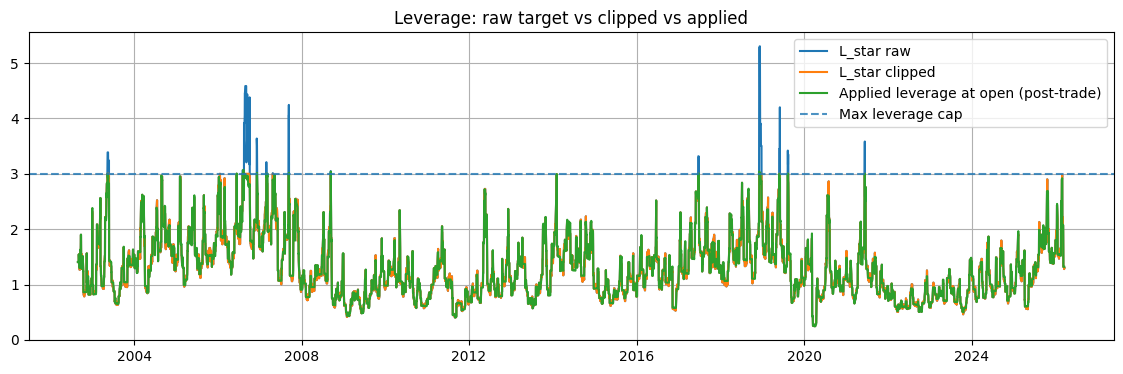

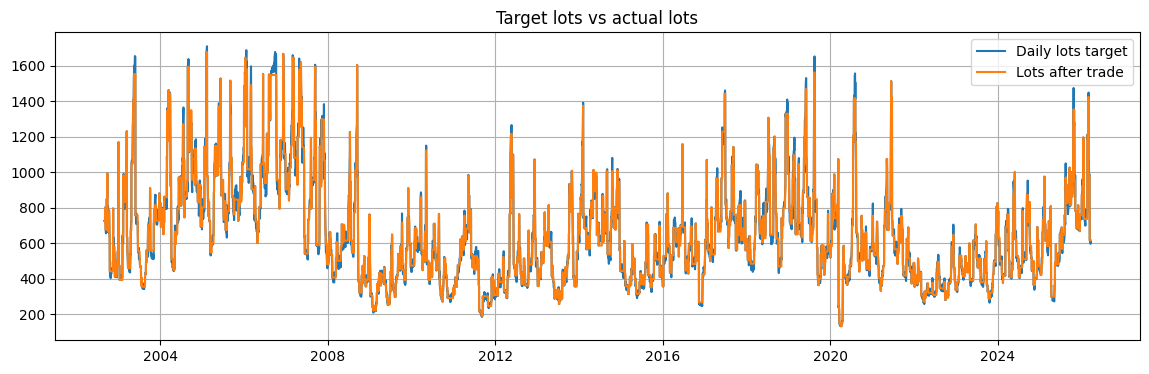

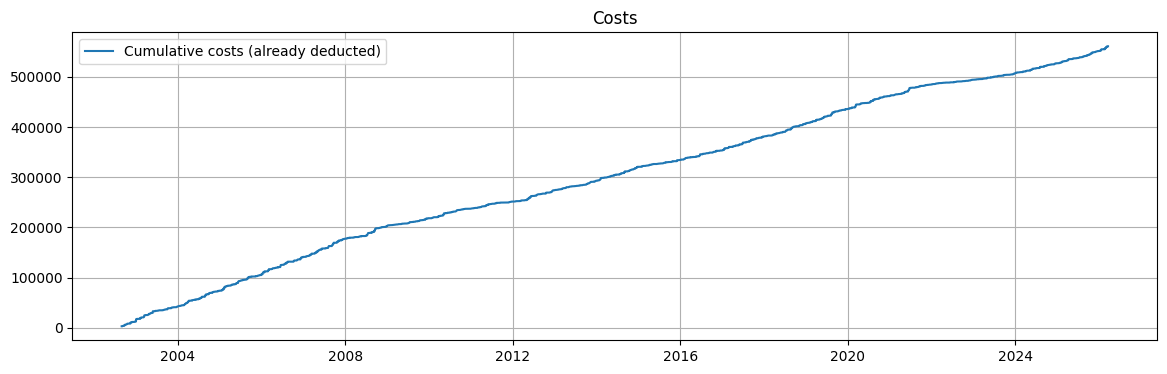

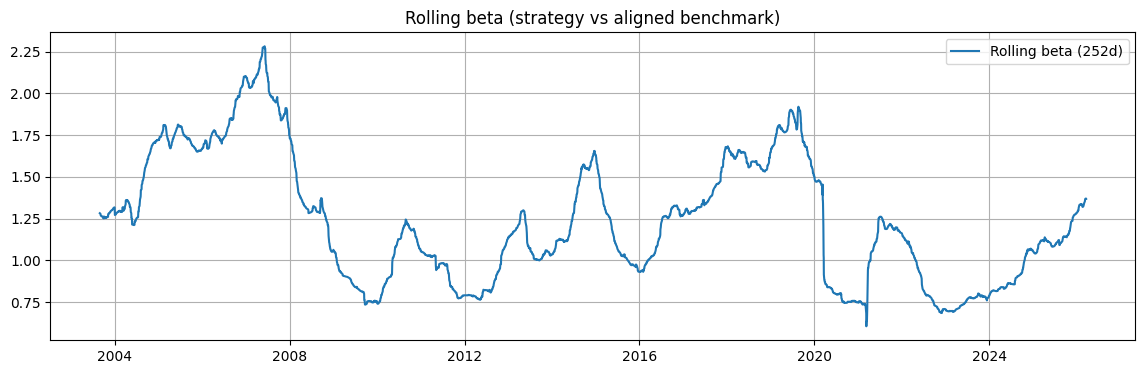

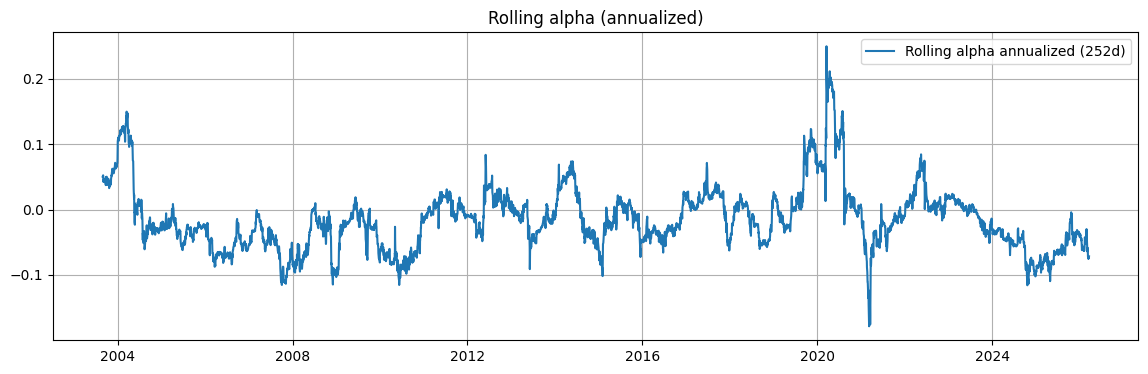


Last 25 trade events:
               date     action  open_mid  NegTarget_dyn  risk_off  L_star_raw   L_star  lots_before  lots_target  lots_after  deltaLots  chunks  commission  spread_cost  slippage_cost  order_fees  cost_total  L_cur_before  rv1_down_agg
2025-08-29 04:00:00   REBAL_UP 84.578825            0.1     False    1.902318 1.902318        825.0        928.0       928.0      103.0     103       412.0          0.0            0.0         0.0       412.0      1.689635      0.052567
2025-09-02 04:00:00 REBAL_DOWN 83.794594            0.1     False    1.721574 1.721574        928.0        833.0       833.0      -95.0      95       380.0          0.0            0.0         0.0       380.0      1.917129      0.058086
2025-09-17 04:00:00   REBAL_UP 88.765705            0.1     False    2.036893 2.036893        833.0       1025.0      1025.0      192.0     192       768.0          0.0            0.0         0.0       768.0      1.654375      0.049094
2025-09-19 04:00:00 REBAL_DOWN 87

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

# =========================================================
# Constant Downside-Vol Targeting Backtest
# - Full negative vol target = 20%
# - Max leverage cap = 3
# - Downside realized vol windows = 21, 63, 126
# =========================================================

# ================== Data source switch ==================
USE_YF = True  # set False to load from MT5 CSV/TSV

# ----- Requested analysis window -----
symbol = "TLT"
start = "2000-01-01"
end   = "2026-03-23"

# ----- MT5 export (if USE_YF=False) -----
csv_path = r"C:\Users\Juanan\Downloads\ES_H_Daily_201001010000_202602260000.csv"
mt5_sep = "\t"

# ================== Inputs ==================
TARGET_NEG_VOL = 0.10

FINAL_TARGET_VOL_FLOOR = 0.00
FINAL_TARGET_VOL_CAP   = 0.20

VolWindows = [21, 63, 126]
UseMaxAcrossWindows = True
RealizedVolFloor = 0.01
MAR = 0.0

MaxLeverage = 3.0
MinLeverage = 0.0

RebalanceUp   = 0.10
RebalanceDown = 0.10
FlatEps       = 0.0

# ================== Rolling alpha/beta ==================
ROLLING_AB_WINDOW = 252
TRADING_DAYS = 252
MAR_EQ_RET = 0.0

# ================== Contract specs ==================
TickSize   = 0.25
TickValue  = 12.5
PointValue = TickValue / TickSize  # 50 USD per 1.00 point

# ================== Volume constraints ==================
MinLot   = 1.0
LotStep  = 1.0
MaxLot   = 99999999999999999999.0

# Chunking
LotsPerChunk = 1.0  # set 0 to disable

# ================== Costs ==================
commission_per_lot_per_side = 4.0
slippage_points             = 0.0
spread_points               = 0.0
per_order_fee               = 0.0

init_cash = 1_000_000.0

# ================== Helpers ==================
def is_weekend(ts: pd.Timestamp) -> bool:
    return ts.weekday() >= 5

def make_index_tz_naive(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)
    return df

def drawdown_from_equity(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def neg_annualized_vol_from_returns(rets: pd.Series, mar: float = 0.0, freq: int = 252) -> float:
    rets = rets.dropna()
    if len(rets) == 0:
        return float("nan")
    d = np.minimum(rets.to_numpy(dtype=float) - float(mar), 0.0)
    return float(np.sqrt(np.mean(d * d)) * np.sqrt(freq))

def perf_stats_from_equity(eq: pd.Series, freq: int = 252, mar_eq_ret: float = 0.0) -> dict:
    eq = eq.dropna()
    if len(eq) < 2:
        return {
            "total_return": np.nan,
            "cagr": np.nan,
            "ann_vol": np.nan,
            "neg_ann_vol": np.nan,
            "sharpe": np.nan,
            "max_dd": np.nan
        }

    rets = eq.pct_change().dropna()
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    years = (len(eq) - 1) / freq
    cagr = float((eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1.0) if years > 0 else np.nan

    ann_vol = float(rets.std(ddof=0) * np.sqrt(freq)) if len(rets) > 1 else np.nan
    neg_ann_vol = neg_annualized_vol_from_returns(rets, mar=mar_eq_ret, freq=freq)
    sharpe = float((rets.mean() * freq) / ann_vol) if ann_vol and ann_vol != 0 else np.nan
    max_dd = float(drawdown_from_equity(eq).min())

    return {
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "neg_ann_vol": neg_ann_vol,
        "sharpe": np.nan if ann_vol == 0 or pd.isna(ann_vol) else sharpe,
        "max_dd": max_dd
    }

def profit_metrics_from_equity(eq: pd.Series, init_cash_ref: float) -> dict:
    eq = eq.dropna()
    if len(eq) == 0:
        return {
            "total_net_profit": np.nan,
            "gross_profit": np.nan,
            "gross_loss": np.nan
        }

    pnl = eq.diff().dropna()
    gross_profit = float(pnl[pnl > 0].sum())
    gross_loss = float(-pnl[pnl < 0].sum())
    total_net_profit = float(eq.iloc[-1] - init_cash_ref)

    return {
        "total_net_profit": total_net_profit,
        "gross_profit": gross_profit,
        "gross_loss": gross_loss
    }

def normalize_lots_scalar(lots: float) -> float:
    lots = min(max(lots, 0.0), MaxLot)
    lots = np.floor(lots / LotStep) * LotStep
    if lots < MinLot:
        return 0.0
    return float(lots)

def lots_for_notional_scalar(notional: float, price_mid: float, point_value: float) -> float:
    if notional <= 0.0 or price_mid <= 0.0 or point_value <= 0.0:
        return 0.0
    return normalize_lots_scalar(notional / (price_mid * point_value))

def chunk_plan(delta_lots: float, lots_per_chunk: float) -> list:
    delta_lots = float(delta_lots)
    if abs(delta_lots) < 1e-12:
        return []
    if lots_per_chunk is None or lots_per_chunk <= 0:
        return [delta_lots]

    sign = 1.0 if delta_lots > 0 else -1.0
    remaining = abs(delta_lots)

    chunks = []
    step = max(LotStep, 1e-12)
    chunk_size = max(lots_per_chunk, step)

    while remaining >= step - 1e-12:
        this = min(chunk_size, remaining)
        this = np.floor(this / step) * step
        if this < step - 1e-12:
            break
        chunks.append(sign * float(this))
        remaining -= float(this)

    return chunks

def downside_realized_vol(close_s: pd.Series, window: int, mar: float = 0.0,
                          floor: float = 0.0, ann_factor: float = 252.0) -> pd.Series:
    r = np.log(close_s / close_s.shift(1))
    d = np.minimum(r - mar, 0.0)
    rv_down = d.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)
    if floor is not None and floor > 0:
        rv_down = rv_down.clip(lower=floor)
    return rv_down

def rolling_alpha_beta(strat_ret: pd.Series, bench_ret: pd.Series, window: int = 252, ann_factor: int = 252):
    df_ab = pd.concat([strat_ret.rename("S"), bench_ret.rename("B")], axis=1).dropna()
    if df_ab.empty:
        return (pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float))

    S = df_ab["S"]
    B = df_ab["B"]

    meanS = S.rolling(window).mean()
    meanB = B.rolling(window).mean()
    covSB = S.rolling(window).cov(B)
    varB  = B.rolling(window).var()

    beta = covSB / varB
    alpha_daily = meanS - beta * meanB
    alpha_ann = alpha_daily * ann_factor

    return alpha_daily.reindex(strat_ret.index), beta.reindex(strat_ret.index), alpha_ann.reindex(strat_ret.index)

# ================== Warmup planning ==================
requested_start_ts = pd.to_datetime(start)
requested_end_ts   = pd.to_datetime(end)

max_window = int(np.max(VolWindows))
max_warmup = max(max_window, ROLLING_AB_WINDOW)

warmup_buffer_days = max_warmup + 10
warmup_start_ts = requested_start_ts - pd.offsets.BDay(warmup_buffer_days)

# ================== Load data ==================
if USE_YF:
    data = vbt.YFData.download(symbol, start=warmup_start_ts.strftime("%Y-%m-%d"), end=end)
    df = data.get()
    df = df.rename(columns={c: c.capitalize() for c in df.columns})
    if "Open" not in df.columns or "Close" not in df.columns:
        raise ValueError(f"YF data missing Open/Close. Columns: {df.columns.tolist()}")
    df = df[["Open", "Close"]].copy()
    df.index = pd.to_datetime(df.index)
    df = make_index_tz_naive(df)
else:
    raw = pd.read_csv(csv_path, sep=mt5_sep)
    raw["date"] = pd.to_datetime(raw["<DATE>"], format="%Y.%m.%d")
    raw = raw.set_index("date").sort_index()
    df = raw.rename(columns={"<OPEN>": "Open", "<CLOSE>": "Close"})[["Open", "Close"]].astype(float)
    df = make_index_tz_naive(df)

df = df.loc[warmup_start_ts:requested_end_ts].copy()
df = df.loc[~df.index.map(is_weekend)].copy()

open_s  = df["Open"].astype(float)
close_s = df["Close"].astype(float)
dates = df.index
n = len(df)

if n < max_warmup + 3:
    raise ValueError(
        f"Not enough data after filtering for warmup. Need at least {max_warmup + 3} rows, got {n}. "
        f"Try loading earlier history before {requested_start_ts.date()}."
    )

# ================== Downside realized vol signal ==================
rv_down_by_w = {}
for w in VolWindows:
    rv_down_by_w[w] = downside_realized_vol(
        close_s=close_s, window=int(w), mar=MAR, floor=RealizedVolFloor, ann_factor=TRADING_DAYS
    )

rv_df = pd.DataFrame(rv_down_by_w)
rv_down = rv_df.max(axis=1) if UseMaxAcrossWindows else rv_df.mean(axis=1)
rv1 = rv_down.shift(1)

# ================== Constant target vol ==================
NegTarget_dyn = pd.Series(TARGET_NEG_VOL, index=dates, dtype=float).clip(
    lower=FINAL_TARGET_VOL_FLOOR,
    upper=FINAL_TARGET_VOL_CAP
)

risk_off = (NegTarget_dyn <= FINAL_TARGET_VOL_FLOOR + 1e-12).fillna(False)

# ================== Leverage target ==================
L_star_raw = (NegTarget_dyn / rv1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
L_star = L_star_raw.clip(lower=MinLeverage, upper=MaxLeverage)

if FlatEps > 0:
    L_star = L_star.where(L_star >= FlatEps, 0.0)

# ================== Strict input-valid mask ==================
live_input_mask = pd.Series(True, index=dates)
live_input_mask &= rv1.notna()
live_input_mask &= rv_down.notna()
live_input_mask &= NegTarget_dyn.notna()
live_input_mask &= L_star.notna()

for w in VolWindows:
    live_input_mask &= rv_df[w].notna()

# ================== Simulation ==================
equity = pd.Series(np.nan, index=dates)
costs  = pd.Series(0.0, index=dates)
lots_after = pd.Series(0.0, index=dates)
lots_target_series = pd.Series(np.nan, index=dates)
applied_L = pd.Series(0.0, index=dates)
L_cur_open_before = pd.Series(np.nan, index=dates)
L_cur_open_after  = pd.Series(np.nan, index=dates)

risk_off_used = pd.Series(False, index=dates)
target_vol_used = pd.Series(np.nan, index=dates)

trades = []

eq = float(init_cash)
curLots = 0.0
prev_close = float(close_s.iloc[0])

EPS_LOTS = 1e-12

half_spread = float(spread_points) / 2.0
half_spread_cost_per_lot = half_spread * PointValue
slip_cost_per_lot = float(slippage_points) * PointValue

for i in range(n):
    dt = dates[i]
    o_mid = float(open_s.iat[i])
    c_mid = float(close_s.iat[i])

    if not bool(live_input_mask.iat[i]):
        equity.iat[i] = np.nan
        lots_after.iat[i] = curLots
        prev_close = c_mid
        continue

    eq += curLots * (o_mid - prev_close) * PointValue

    Ls = float(L_star.iat[i])
    risk_off_today = bool(risk_off.iat[i])
    target_vol_today = float(NegTarget_dyn.iat[i])

    risk_off_used.iat[i] = risk_off_today
    target_vol_used.iat[i] = target_vol_today

    notional_cur_open = curLots * o_mid * PointValue
    L_cur_before = (notional_cur_open / eq) if eq > 0 else 0.0
    L_cur_open_before.iat[i] = L_cur_before

    lots_target = lots_for_notional_scalar(Ls * eq, o_mid, PointValue) if Ls > 0 else 0.0
    lots_target = normalize_lots_scalar(lots_target)
    lots_target_series.iat[i] = lots_target

    doTrade = False
    increasing_exposure = False

    if curLots <= 0.0 + EPS_LOTS:
        increasing_exposure = (lots_target > 0.0 + EPS_LOTS)
        if increasing_exposure:
            doTrade = True
    else:
        if lots_target <= 0.0 + EPS_LOTS:
            increasing_exposure = False
            doTrade = True
        else:
            rel_change = (abs(Ls - L_cur_before) / L_cur_before) if L_cur_before > 1e-9 else abs(Ls - L_cur_before)
            if Ls > L_cur_before:
                increasing_exposure = True
                doTrade = (rel_change > RebalanceUp)
            else:
                increasing_exposure = False
                doTrade = (rel_change > RebalanceDown)

    lots_before = curLots

    if doTrade:
        deltaLots = lots_target - curLots
        chunks = chunk_plan(deltaLots, LotsPerChunk)

        total_commission  = 0.0
        total_spread_cost = 0.0
        total_slip_cost   = 0.0
        total_order_fees  = 0.0

        for ch in chunks:
            ch_abs = abs(ch)
            if ch_abs < EPS_LOTS:
                continue

            total_commission  += ch_abs * commission_per_lot_per_side
            total_spread_cost += ch_abs * half_spread_cost_per_lot
            total_slip_cost   += ch_abs * slip_cost_per_lot
            total_order_fees  += per_order_fee

            curLots += ch
            curLots = normalize_lots_scalar(curLots)

        total_cost = total_commission + total_spread_cost + total_slip_cost + total_order_fees
        if total_cost != 0.0:
            eq -= total_cost
            costs.iat[i] += total_cost

        if abs(lots_target - lots_before) >= EPS_LOTS and len(chunks) > 0:
            if lots_before <= 0.0 + EPS_LOTS and curLots > 0.0:
                action = "ENTER"
            elif lots_before > 0.0 + EPS_LOTS and curLots <= 0.0 + EPS_LOTS:
                action = "FLAT"
            elif curLots > lots_before:
                action = "REBAL_UP"
            else:
                action = "REBAL_DOWN"

            trades.append({
                "date": dt,
                "action": action,
                "open_mid": o_mid,
                "close_mid": c_mid,
                "rv1_down_agg": float(rv1.iat[i]),
                "NegTarget_dyn": float(NegTarget_dyn.iat[i]),
                "risk_off": risk_off_today,
                "L_star_raw": float(L_star_raw.iat[i]),
                "L_star": Ls,
                "lots_before": lots_before,
                "lots_target": lots_target,
                "lots_after": curLots,
                "deltaLots": (lots_target - lots_before),
                "chunks": len(chunks),
                "commission": total_commission,
                "spread_cost": total_spread_cost,
                "slippage_cost": total_slip_cost,
                "order_fees": total_order_fees,
                "cost_total": total_cost,
                "equity_after_cost": eq,
                "L_cur_before": L_cur_before,
            })

    notional_after_open = curLots * o_mid * PointValue
    L_cur_after = (notional_after_open / eq) if eq > 0 else 0.0
    L_cur_open_after.iat[i] = L_cur_after
    applied_L.iat[i] = L_cur_after

    eq += curLots * (c_mid - o_mid) * PointValue

    equity.iat[i] = eq
    lots_after.iat[i] = curLots
    prev_close = c_mid

trades_df = pd.DataFrame(trades).sort_values("date").reset_index(drop=True) if trades else pd.DataFrame()

# ================== Analysis window ==================
requested_mask = dates >= requested_start_ts
base_mask = requested_mask & live_input_mask

equity_base = equity.loc[base_mask].dropna()
lots_base = lots_after.loc[base_mask]

if len(equity_base) < 2:
    raise ValueError(
        f"No valid post-warmup analysis data available inside requested window "
        f"{requested_start_ts.date()} -> {requested_end_ts.date()}."
    )

exposed_idx = lots_base[lots_base > 0].index
if len(exposed_idx) == 0:
    raise ValueError("Strategy never gets exposure in the requested analysis window.")

strategy_start_ts = exposed_idx.min()
analysis_idx = equity_base.loc[equity_base.index >= strategy_start_ts].index

equity_analysis = equity.loc[analysis_idx]
costs_analysis = costs.loc[analysis_idx]
lots_target_analysis = lots_target_series.loc[analysis_idx]
applied_L_analysis = applied_L.loc[analysis_idx]
L_star_analysis = L_star.loc[analysis_idx]
L_star_raw_analysis = L_star_raw.loc[analysis_idx]
NegTarget_dyn_analysis = NegTarget_dyn.loc[analysis_idx]
risk_off_used_analysis = risk_off_used.loc[analysis_idx]
close_analysis = close_s.loc[analysis_idx]
rv_down_analysis = rv_down.loc[analysis_idx]
rv_df_analysis = rv_df.loc[analysis_idx]

bench_equity = init_cash * (close_analysis / float(close_analysis.iloc[0]))
strategy_equity_rebased = init_cash * (equity_analysis / float(equity_analysis.iloc[0]))
bench_equity_rebased    = init_cash * (bench_equity / float(bench_equity.iloc[0]))

if not trades_df.empty:
    trades_df = trades_df.loc[trades_df["date"] >= strategy_start_ts].reset_index(drop=True)

profit_metrics = profit_metrics_from_equity(strategy_equity_rebased, init_cash_ref=init_cash)

# ================== Rolling alpha/beta ==================
strat_rets = strategy_equity_rebased.pct_change().dropna()
bench_rets = bench_equity_rebased.pct_change().dropna()

ab_idx = strat_rets.index.intersection(bench_rets.index)
strat_rets_al = strat_rets.loc[ab_idx]
bench_rets_al = bench_rets.loc[ab_idx]

alpha_daily, beta, alpha_ann = rolling_alpha_beta(
    strat_ret=strat_rets_al,
    bench_ret=bench_rets_al,
    window=ROLLING_AB_WINDOW,
    ann_factor=TRADING_DAYS
)

# ================== Output ==================
print("=== Constant Downside-Vol Targeting Backtest ===")
print(f"Source: {'Yahoo via vectorbt' if USE_YF else 'MT5 export'} | Symbol: {symbol if USE_YF else 'MT5_FILE'}")
print(f"Requested analysis window: {requested_start_ts.date()} -> {requested_end_ts.date()}")
print(f"Warmup start used: {warmup_start_ts.date()} | Warmup bars target: {warmup_buffer_days}")
print(f"Rows used for full calc: {len(df)} | Rows used for final analysis: {len(analysis_idx)}")
print(f"First valid input date: {equity_base.index.min().date()}")
print(f"First actual exposure date: {strategy_start_ts.date()}")
print(f"Final analysis window: {analysis_idx.min().date()} -> {analysis_idx.max().date()}")
print(f"Constant target negative vol: {TARGET_NEG_VOL}")
print(f"Final target vol floor/cap: {FINAL_TARGET_VOL_FLOOR} -> {FINAL_TARGET_VOL_CAP}")
print(f"VolWindows: {VolWindows} | Aggregation: {'MAX' if UseMaxAcrossWindows else 'MEAN'} | MAR(signal): {MAR}")
print(f"Realized vol floor: {RealizedVolFloor}")
print(f"Max leverage cap: {MaxLeverage}")
print(f"Rolling alpha/beta window: {ROLLING_AB_WINDOW} days")
print(f"PointValue: {PointValue} | MinLot={MinLot}, Step={LotStep}, MaxLot={MaxLot}")
print(f"Commission: ${commission_per_lot_per_side}/lot/side | Spread: {spread_points} pts | Slippage: {slippage_points} pts")
print(f"Total costs deducted (analysis window): {float(costs_analysis.sum()):.2f}")
print()

print("Strategy stats (rebased to init_cash at first exposure date):")
print(perf_stats_from_equity(strategy_equity_rebased, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print("\nProfit metrics (rebased series):")
print(profit_metrics)

print("\nBenchmark stats (rebased, first-exposure aligned):")
print(perf_stats_from_equity(bench_equity_rebased, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

last_beta = beta.dropna().iloc[-1] if beta.dropna().shape[0] else np.nan
last_alpha_ann = alpha_ann.dropna().iloc[-1] if alpha_ann.dropna().shape[0] else np.nan
print("\nRolling alpha/beta (latest available):")
print({
    "beta": float(last_beta) if np.isfinite(last_beta) else np.nan,
    "alpha_ann": float(last_alpha_ann) if np.isfinite(last_alpha_ann) else np.nan
})

print("\nTrade counts:")
if trades_df.empty:
    print({"total_trade_events_logged": 0})
else:
    print({
        "enter": int((trades_df["action"] == "ENTER").sum()),
        "rebal_up": int((trades_df["action"] == "REBAL_UP").sum()),
        "rebal_down": int((trades_df["action"] == "REBAL_DOWN").sum()),
        "flat": int((trades_df["action"] == "FLAT").sum()),
        "total_trade_events_logged": int(len(trades_df))
    })

# ================== Plots ==================
plt.figure(figsize=(14, 6))
plt.plot(strategy_equity_rebased, label="Strategy equity (rebased)")
plt.plot(bench_equity_rebased, label="Benchmark equity (rebased)")
plt.yscale("log")
plt.title("Equity curves (log, rebased) - starts at first actual exposure date")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(drawdown_from_equity(strategy_equity_rebased), label="Strategy drawdown")
plt.plot(drawdown_from_equity(bench_equity_rebased), label="Benchmark drawdown")
plt.title("Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for w in VolWindows:
    plt.plot((rv_df_analysis[w] * 100.0), linewidth=1.2, alpha=0.8, label=f"Downside RV ({w}) %")
plt.plot((rv_down_analysis * 100.0), linewidth=2.5, label=f"Aggregated RV ({'MAX' if UseMaxAcrossWindows else 'MEAN'}) %")
plt.title("Downside realized volatility (21 / 63 / 126)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(NegTarget_dyn_analysis, linewidth=2.0, label="Constant target negative vol")
plt.axhline(TARGET_NEG_VOL, linestyle="--", alpha=0.7, label="Target neg vol")
plt.title("Constant negative volatility target")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(L_star_raw_analysis, label="L_star raw")
plt.plot(L_star_analysis, label="L_star clipped")
plt.plot(applied_L_analysis, label="Applied leverage at open (post-trade)")
plt.axhline(MaxLeverage, linestyle="--", alpha=0.8, label="Max leverage cap")
plt.title("Leverage: raw target vs clipped vs applied")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(lots_target_analysis, label="Daily lots target")
plt.plot(lots_after.loc[analysis_idx], label="Lots after trade")
plt.title("Target lots vs actual lots")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(costs_analysis.cumsum(), label="Cumulative costs (already deducted)")
plt.title("Costs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(beta, label=f"Rolling beta ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling beta (strategy vs aligned benchmark)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(alpha_ann, label=f"Rolling alpha annualized ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling alpha (annualized)")
plt.grid(True)
plt.legend()
plt.show()

if trades_df.empty:
    print("\nNo trade events logged.")
else:
    print("\nLast 25 trade events:")
    cols = [
        "date", "action", "open_mid",
        "NegTarget_dyn", "risk_off", "L_star_raw", "L_star",
        "lots_before", "lots_target", "lots_after", "deltaLots", "chunks",
        "commission", "spread_cost", "slippage_cost", "order_fees", "cost_total",
        "L_cur_before", "rv1_down_agg"
    ]
    print(trades_df[cols].tail(25).to_string(index=False))